In [1]:
import json
import pandas as pd

# 1. Crear ventas.csv
df_ventas_mock = pd.DataFrame(
    {
        "id_venta": [101, 102, 103, 104, 105],
        "id_cliente": [1, 2, 1, 3, 2],
        "id_producto": ["P01", "P02", "P03", "P01", "P02"],
        "cantidad": [2, 1, 5, 1, 3],
        "total": [2400.0, 1500.0, 4500.0, 1200.0, 4500.0],
    }
)
df_ventas_mock.to_csv("ventas.csv", index=False)

# 2. Crear clientes.json
clientes_mock = [
    {"id_cliente": 1, "nombre": "Carlos Gómez", "ciudad": "Río Grande"},
    {"id_cliente": 2, "nombre": "Marina Rossi", "ciudad": "Ushuaia"},
    {"id_cliente": 3, "nombre": "Laura Pérez", "ciudad": "Tolhuin"},
]
with open("clientes.json", "w", encoding="utf-8") as f:
  json.dump(clientes_mock, f, ensure_ascii=False, indent=4)

# 3. Crear inventario.xlsx
df_inventario_mock = pd.DataFrame(
    {
        "id_producto": ["P01", "P02", "P03", "P04"],
        "producto": ["Teclado USB", "Mouse Inalámbrico", "Monitor 24", "Auriculares"],
        "precio": [1200.0, 1500.0, 900.0, 800.0],
        "stock": [45, 80, 15, 30],
    }
)
df_inventario_mock.to_excel("inventario.xlsx", index=False)

print("Archivos generados con éxito.")

Archivos generados con éxito.


In [2]:
import pandas as pd

# Cargar datos de ventas y mostrar primeras filas
ventas = pd.read_csv('ventas.csv')
print("--- TAREA 1: Primeras filas de Ventas (CSV) ---")
ventas.head()

--- TAREA 1: Primeras filas de Ventas (CSV) ---


,id_venta,id_cliente,id_producto,cantidad,total
0,101,1,P01,2,2400.0
1,102,2,P02,1,1500.0
2,103,1,P03,5,4500.0
3,104,3,P01,1,1200.0
4,105,2,P02,3,4500.0


In [3]:
# Cargar datos de clientes y mostrar cantidad total
clientes = pd.read_json('clientes.json')
total_clientes = len(clientes)
print(f"Total de clientes registrados: {total_clientes}")

Total de clientes registrados: 3


In [4]:
# Cargar inventario y calcular promedio de stock
inventario = pd.read_excel('inventario.xlsx')
promedio_stock = inventario['stock'].mean()
print(f"Promedio de stock disponible: {promedio_stock:.2f} unidades")

Promedio de stock disponible: 42.50 unidades


In [5]:
# Combinar las tres fuentes en un único DataFrame
df_completo = ventas.merge(clientes, on='id_cliente', how='left').merge(inventario, on='id_producto', how='left')
df_completo

,id_venta,id_cliente,id_producto,cantidad,total,nombre,ciudad,producto,precio,stock
0,101,1,P01,2,2400.0,Carlos Gómez,Río Grande,Teclado USB,1200,45
1,102,2,P02,1,1500.0,Marina Rossi,Ushuaia,Mouse Inalámbrico,1500,80
2,103,1,P03,5,4500.0,Carlos Gómez,Río Grande,Monitor 24,900,15
3,104,3,P01,1,1200.0,Laura Pérez,Tolhuin,Teclado USB,1200,45
4,105,2,P02,3,4500.0,Marina Rossi,Ushuaia,Mouse Inalámbrico,1500,80


In [6]:
import matplotlib.pyplot as plt
import pandas as pd

# Cargar el archivo recién subido
df_auto = pd.read_csv('Automobile.csv')

# Tratamiento de valores faltantes comunes en horsepower (como '?')
if 'horsepower' in df_auto.columns:
  df_auto['horsepower'] = pd.to_numeric(
      df_auto['horsepower'].replace('?', None), errors='coerce'
  )

df_auto.dropna(inplace=True)
print(f'Total de registros cargados y limpios: {len(df_auto)}')
df_auto.head()

Matplotlib is building the font cache; this may take a moment.


Total de registros cargados y limpios: 392


,name,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin
0,chevrolet chevelle malibu,18.0,8,307.0,130.0,3504,12.0,70,usa
1,buick skylark 320,15.0,8,350.0,165.0,3693,11.5,70,usa
2,plymouth satellite,18.0,8,318.0,150.0,3436,11.0,70,usa
3,amc rebel sst,16.0,8,304.0,150.0,3433,12.0,70,usa
4,ford torino,17.0,8,302.0,140.0,3449,10.5,70,usa


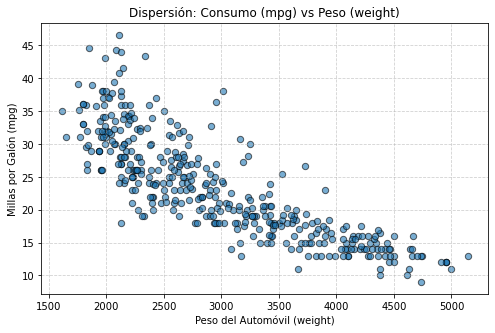

In [7]:
plt.figure(figsize=(8, 5))
plt.scatter(
    df_auto['weight'],
    df_auto['mpg'],
    color='#1f77b4',
    alpha=0.6,
    edgecolors='k',
    s=40,
)
plt.title('Dispersión: Consumo (mpg) vs Peso (weight)')
plt.xlabel('Peso del Automóvil (weight)')
plt.ylabel('Millas por Galón (mpg)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

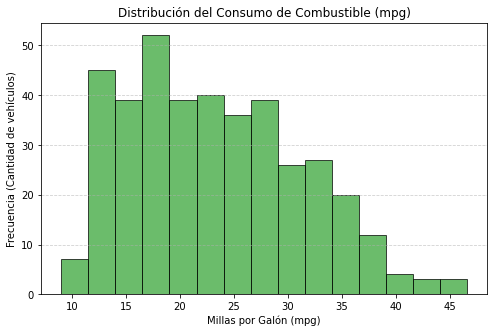

In [8]:
plt.figure(figsize=(8, 5))
plt.hist(df_auto['mpg'], bins=15, color='#2ca02c', edgecolor='black', alpha=0.7)
plt.title('Distribución del Consumo de Combustible (mpg)')
plt.xlabel('Millas por Galón (mpg)')
plt.ylabel('Frecuencia (Cantidad de vehículos)')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

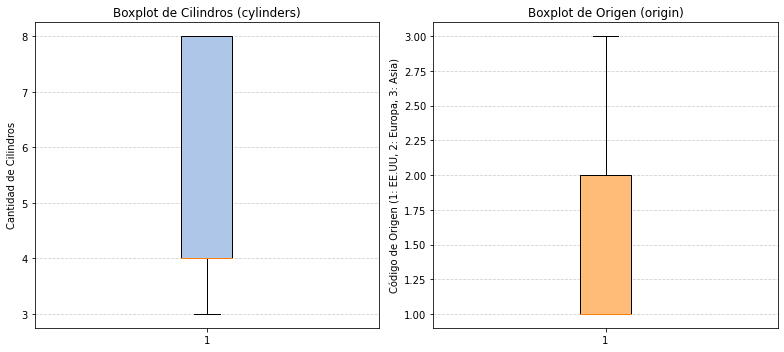

In [10]:
import matplotlib.pyplot as plt
import pandas as pd

# Asegurar que origin sea numérico según la consigna (1: USA, 2: Europa, 3: Asia)
if df_auto['origin'].dtype == 'object':
  df_auto['origin'] = (
      df_auto['origin']
      .str.lower()
      .str.strip()
      .map({'usa': 1, 'europe': 2, 'japan': 3})
  )

# Convertir explícitamente a tipo numérico
df_auto['cylinders'] = pd.to_numeric(df_auto['cylinders'], errors='coerce')
df_auto['origin'] = pd.to_numeric(df_auto['origin'], errors='coerce')

# Eliminar nulos si hubiera quedado alguno
datos_box = df_auto[['cylinders', 'origin']].dropna()

fig, axes = plt.subplots(1, 2, figsize=(11, 5))

# Boxplot para Cilindros
axes[0].boxplot(
    datos_box['cylinders'],
    patch_artist=True,
    boxprops=dict(facecolor='#aec7e8'),
)
axes[0].set_title('Boxplot de Cilindros (cylinders)')
axes[0].set_ylabel('Cantidad de Cilindros')
axes[0].grid(axis='y', linestyle='--', alpha=0.6)

# Boxplot para Origen (1: EE.UU., 2: Europa, 3: Asia)
axes[1].boxplot(
    datos_box['origin'],
    patch_artist=True,
    boxprops=dict(facecolor='#ffbb78'),
)
axes[1].set_title('Boxplot de Origen (origin)')
axes[1].set_ylabel('Código de Origen (1: EE.UU, 2: Europa, 3: Asia)')
axes[1].grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

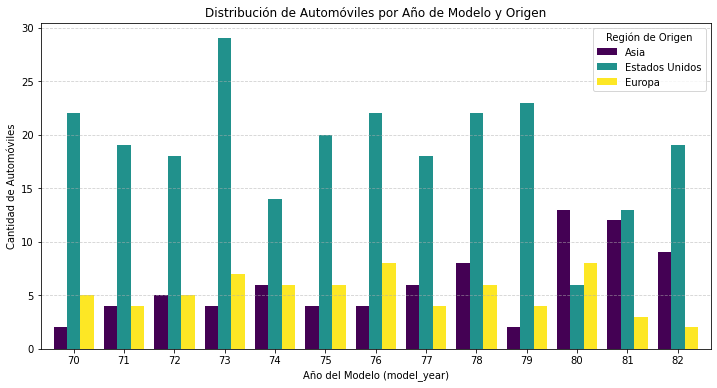

In [11]:
import matplotlib.pyplot as plt
import pandas as pd

# Mapear los códigos numéricos a nombres para la leyenda
mapeo_origen = {1: 'Estados Unidos', 2: 'Europa', 3: 'Asia'}
df_conteo = df_auto.copy()
df_conteo['origen_nombre'] = df_conteo['origin'].map(mapeo_origen)

# Crear tabla cruzada de frecuencias: filas=año, columnas=origen
tabla_contingencia = pd.crosstab(
    df_conteo['model_year'], df_conteo['origen_nombre']
)

# Graficar barras agrupadas
tabla_contingencia.plot(
    kind='bar', figsize=(12, 6), colormap='viridis', width=0.8
)
plt.title('Distribución de Automóviles por Año de Modelo y Origen')
plt.xlabel('Año del Modelo (model_year)')
plt.ylabel('Cantidad de Automóviles')
plt.legend(title='Región de Origen')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()